## Exploring the Dataset
This notebook explores the Touch-Ex dataset by using the developed pipeline functions found in the data directory.

In [1]:
# Allow imports from the parent directory
import sys
import os

module_path = os.path.abspath(os.path.join(".."))
sys.path.append(module_path)

In [2]:
# Imports
import torchvision
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from data.dataset import TouchExDataset
import data.utils as utils
import json

In [3]:
# Get default data config from json file
with open("../configs/default_data_config.json", "r", encoding="utf-8") as f:
    data_config = json.load(f)
data_config

{'random_state': 129,
 'split_size': 0.2,
 'stratify_label': 'object',
 'filtered_force_level': None,
 'filtered_motion': None,
 'transform_name': 'pad_224',
 'bg_path': 'data/baseline.jpg',
 'norm_type': 'dataset',
 'norm_cache_path': 'configs/norm_cache.json',
 'batch_size': 64,
 'num_workers': 4,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

In [4]:
# Make some changes to the data_config
data_config["bg_path"] = None  # Don't subtract bg image for this notebook
data_config["norm_cache_path"] = "../configs/norm_cache.json"  # Relative path

### Load Data

In [5]:
# Load the dataset into DataFrames
dfs = utils.load_touch_ex_dataset()
dfs.keys()

dict_keys(['train', 'test_unseen'])

In [6]:
# Extract the training and test_unseen DataFrames from the dictionary
train_df = dfs["train"]
test_unseen_df = dfs["test_unseen"]

In [7]:
# View the first few rows of the training DataFrame
train_df.head(3)

,image,object,region,object_region,force_level,motion,fsr_voltage,force_n,hardness,material,description,interaction_num,frame_num,interaction_id
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,sliding,0.016114,0.014450,medium,pu leather,"A firm, compressible spherical PU leather surf...",0001,0001,football_panels_force1_interaction0001
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,sliding,0.020948,0.018785,medium,pu leather,"A firm, compressible spherical PU leather surf...",0001,0002,football_panels_force1_interaction0001
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,sliding,0.016114,0.014450,medium,pu leather,"A firm, compressible spherical PU leather surf...",0001,0003,football_panels_force1_interaction0001


In [8]:
# Add new columns to test_unseen_df for expected labels
test_unseen_df = utils.add_expected_labels(test_unseen_df)
# View the first few rows of the test_unseen DataFrame
test_unseen_df.head(3)

,image,object,region,object_region,force_level,motion,fsr_voltage,force_n,hardness,material,description,interaction_num,frame_num,interaction_id,expected_object,expected_object_region
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.045118,0.040459,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0001,beaker_body_force1_interaction0001,mug,mug_body
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.033838,0.030345,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0002,beaker_body_force1_interaction0001,mug,mug_body
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.029004,0.026010,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0003,beaker_body_force1_interaction0001,mug,mug_body


In [9]:
# Split the main training set into training, validation, and test sets
# The split is done by interaction to ensure that all samples from a given interaction are in the same set to avoid data leakage  # noqa: E501
train_df, val_df, test_df = utils.split_by_interaction(
    train_df,
    split_size=data_config["split_size"],
    stratify_label=data_config["stratify_label"],
    random_state=data_config["random_state"],
)

Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120


In [ ]:
# Split the unseen test data into matched and related sets
test_unseen_matched_df, test_unseen_related_df = utils.split_test_unseen(test_unseen_df)

In [11]:
test_unseen_matched_df["object"].unique()

<ArrowStringArray>
['media_remote', 'patterned_mug', 'small_scissors', 'tin_peas']
Length: 4, dtype: str

In [12]:
test_unseen_related_df["object"].unique()

<ArrowStringArray>
['beaker', 'dish_brush', 'microfibre_cloth', 'rubber_ball', 'table_knife']
Length: 5, dtype: str

In [13]:
# Get label mappings for the training, matched, and related unseen sets.
mappings = {
    "train": utils.get_label_mappings(train_df),
    "test_unseen_matched": utils.get_label_mappings(test_unseen_matched_df),
    "test_unseen_related": utils.get_label_mappings(test_unseen_related_df),
}

In [14]:
# Extract the idx2label mappings for training and unseen test sets
# This is so we can use them later to convert model predictions back to readable labels
train_idx2label = mappings["train"]["idx2label"]
test_unseen_matched_idx2label = mappings["test_unseen_matched"]["idx2label"]
test_unseen_related_idx2label = mappings["test_unseen_related"]["idx2label"]

In [ ]:
# View the mapping for the training set "object" label
train_idx2label["object"]

{0: 'football',
 1: 'hammer',
 2: 'mug',
 3: 'plastic_bottle',
 4: 'scissors',
 5: 'sponge_scourer',
 6: 'tea_towel',
 7: 'tennis_ball',
 8: 'tin_beans',
 9: 'toilet_roll',
 10: 'toothbrush',
 11: 'tube_pringles',
 12: 'tv_remote',
 13: 'wooden_spoon'}

In [16]:
# View the mapping for the test_unseen_matched set "object" label
test_unseen_matched_idx2label["object"]

{0: 'media_remote', 1: 'patterned_mug', 2: 'small_scissors', 3: 'tin_peas'}

In [17]:
# View the mapping for the test_unseen_related set "object" label
test_unseen_related_idx2label["object"]

{0: 'beaker',
 1: 'dish_brush',
 2: 'microfibre_cloth',
 3: 'rubber_ball',
 4: 'table_knife'}

In [18]:
# Get normalisation statistics from the training set for this dataset configuration
# If a cache file exists, it will be loaded instead of recomputing the statistics
norm_stats = utils.get_norm_stats(train_df, data_config)
norm_stats

Norm cache found, loading normalisation stats.


(tensor([0.2994, 0.3097, 0.2898]), tensor([0.2496, 0.2184, 0.2029]))

### TouchFL Dataset

#### Training Data

In [19]:
# Create a dataset object for the training set using the TouchExDataset class
train_dataset = TouchExDataset(
    dataframe=train_df,
    split="train",
    mappings=mappings,
    transform_name=data_config["transform_name"],
    norm_stats=norm_stats,
    bg_path=data_config["bg_path"],
)

In [20]:
# Get a sample from the training dataset and display its keys
sample = train_dataset[0]
sample.keys()

dict_keys(['image', 'force_n', 'fsr_voltage', 'hardness', 'material', 'description', 'interaction_num', 'frame_num', 'interaction_id', 'object', 'region', 'object_region', 'force_level', 'motion'])

In [21]:
# Display the shapes of the image tensor and the values of the other features in the sample
for k, v in sample.items():
    print(f"{k}: {v.shape if k == 'image' else v}")

image: torch.Size([3, 224, 224])
force_n: 0.00939237605780363
fsr_voltage: 0.010473792441189289
hardness: medium
material: pu leather
description: A firm, compressible spherical PU leather surface consisting of individual hexagonal panels with a repeating micro-texture of fine, wavy lines and a small circular recessed opening on one panel.
interaction_num: 0002
frame_num: 0001
interaction_id: football_panels_force1_interaction0002
object: 0
region: 0
object_region: 0
force_level: 0
motion: 0


In [22]:
# Use the label mappings to convert the class indexes back to readable class names
for k in train_idx2label.keys():
    mapping = train_idx2label[k]
    class_idx = sample[k].item()
    class_name = mapping[class_idx]
    print(f"{k}: {class_name} (class index: {class_idx})")

object: football (class index: 0)
region: panels (class index: 0)
object_region: football_panels (class index: 0)
force_level: 1 (class index: 0)
motion: sliding (class index: 0)


#### Unseen Test Data

In [23]:
# Create a dataset object for the test_unseen_matched set using the TouchExDataset class
test_unseen_matched_dataset = TouchExDataset(
    dataframe=test_unseen_matched_df,
    split="test_unseen_matched",
    mappings=mappings,
    transform_name=data_config["transform_name"],
    norm_stats=norm_stats,
    bg_path=data_config["bg_path"],
)

In [24]:
# Get a sample from the test_unseen_matched dataset and display its keys
sample = test_unseen_matched_dataset[0]
sample.keys()

dict_keys(['image', 'force_n', 'fsr_voltage', 'hardness', 'material', 'description', 'interaction_num', 'frame_num', 'interaction_id', 'object', 'region', 'object_region', 'force_level', 'motion', 'expected_object', 'expected_object_region'])

In [25]:
# Display the shapes of the image tensor and the values of the other features in the sample
for k, v in sample.items():
    print(f"{k}: {v.shape if k == 'image' else v}")

image: torch.Size([3, 224, 224])
force_n: 0.014449811540544033
fsr_voltage: 0.0161135271191597
hardness: hard
material: plastic
description: An elongated matte plastic casing with a wedge-like profile, featuring sloping side faces, rounded edges, tapered ends, and four small circular raised feet on the rear surface.
interaction_num: 0001
frame_num: 0001
interaction_id: media_remote_body_force1_interaction0001
object: 0
region: 0
object_region: 0
force_level: 0
motion: 0
expected_object: 12
expected_object_region: 29


In [26]:
# Use the label mappings to convert the class indexes back to readable class names
for k in test_unseen_matched_idx2label.keys():
    mapping = test_unseen_matched_idx2label[k]
    class_idx = sample[k].item()
    class_name = mapping[class_idx]
    print(f"{k}: {class_name} (class index: {class_idx})")

# Expected labels are encoded in the training label spaces
expected_label_targets = {
    "expected_object": "object",
    "expected_object_region": "object_region",
}
for expected_label, train_label in expected_label_targets.items():
    mapping = train_idx2label[train_label]
    class_idx = sample[expected_label].item()
    class_name = mapping[class_idx]
    print(f"{expected_label}: {class_name} (class index: {class_idx})")

object: media_remote (class index: 0)
region: body (class index: 0)
object_region: media_remote_body (class index: 0)
force_level: 1 (class index: 0)
motion: sliding (class index: 0)
expected_object: tv_remote (class index: 12)
expected_object_region: tv_remote_body (class index: 29)


### Data Loader and Visualisation

In [27]:
# Create a small batch size dataloader for training set visualisation
viz_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
data = next(iter(viz_dataloader))

In [28]:
# Extract the inputs and object labels from the batch of data
inputs, labels = data["image"], data["object"]
# Create a grid of the input images for visualisation using torchvision's make_grid function
grid = torchvision.utils.make_grid(inputs)

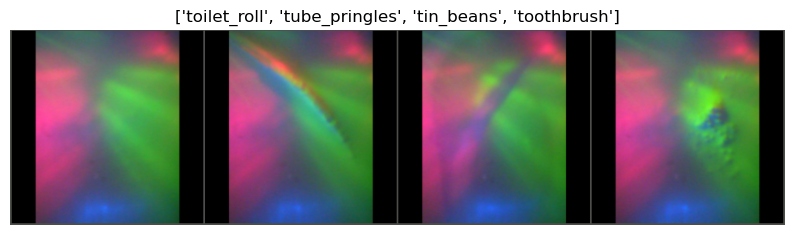

In [29]:
# Un-normalise the grid while it is still a torch tensor in (C, H, W) format
mean = norm_stats[0].view(-1, 1, 1)
std = norm_stats[1].view(-1, 1, 1)
input = (grid * std + mean).clamp(0, 1)
# Convert the grid image tensor to a numpy array in (H, W, C) format for display
input = input.permute(1, 2, 0).numpy()
# Display the image using matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(input)
plt.title([train_idx2label["object"][idx.item()] for idx in labels])
plt.axis("off")
plt.show()